In [34]:
import pandas as pd
import scanpy as sc
from scipy.spatial.distance import pdist, squareform
import warnings

In [ ]:
import pandas as pd
import anndata as ad

# Load expression matrix
expr = pd.read_csv("Run1000_S1_Half_exprMat_file.csv")

# Remove unassigned transcripts/cells
expr = expr[expr["cell_ID"] != 0]

# Create unique IDs
expr["unique_cell"] = (
    expr["fov"].astype(str) + "_" +
    expr["cell_ID"].astype(str)
)

expr = expr.set_index("unique_cell")

# Remove indexing columns
gene_matrix = expr.drop(columns=["fov", "cell_ID"])

# Create AnnData
adata = ad.AnnData(gene_matrix)

# Load metadata
meta = pd.read_csv("Run1000_S1_Half_metadata_file.csv")

meta["unique_cell"] = (
    meta["fov"].astype(str) + "_" +
    meta["cell_ID"].astype(str)
)

meta = meta.set_index("unique_cell")

# Match metadata to AnnData
meta = meta.loc[adata.obs_names]

# Store metadata
adata.obs = meta

# Add spatial coordinates
adata.obsm["spatial"] = meta[
    ["CenterX_global_px", "CenterY_global_px"]
].values

print(adata)

In [ ]:
import scanpy as sc

adata = sc.read("brain_data.h5ad")

In [25]:
adata.obs

,fov,cell_ID,Area,AspectRatio,CenterX_local_px,CenterY_local_px,CenterX_global_px,CenterY_global_px,Width,Height,Mean.Histone,Max.Histone,Mean.G,Max.G,Mean.rRNA,Max.rRNA,Mean.GFAP,Max.GFAP,Mean.DAPI,Max.DAPI
unique_cell,,,,,,,,,,,,,,,,,,,,
1_1,1,1,6073,0.47,4222,4066,-494161.333333,10541.000000,66,141,7095,42463,70,4044,376,2871,42,3313,65,233
1_2,1,2,5675,0.72,4182,3938,-494201.333333,10413.000000,101,140,9220,39045,82,296,642,1486,36,527,88,287
1_3,1,3,12896,1.26,2156,3864,-496227.333333,10339.000000,153,121,16993,45967,78,1652,109,1538,37,1797,35,249
1_4,1,4,8234,0.51,4108,3608,-494275.333333,10083.000000,81,160,12720,31967,121,3074,664,3284,71,3625,219,540
1_5,1,5,9852,0.88,4162,3506,-494221.333333,9981.000000,117,133,11177,38479,99,3173,444,2946,82,2957,251,628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130_311,130,311,4227,0.81,748,1588,-454977.000000,-21553.666667,69,85,2849,11681,20,85,97,964,133,1178,216,1488
130_312,130,312,2691,0.91,1407,1384,-454318.000000,-21757.666667,59,65,4337,10654,24,86,311,1541,31,221,68,229
130_313,130,313,9075,1.12,1466,883,-454259.000000,-22258.666667,129,115,18544,48924,87,242,133,758,18,497,355,1614


In [ ]:
coords_mat = adata.obsm["spatial"]

array([[-494161.33333333,   10541.        ],
       [-494201.33333333,   10413.        ],
       [-496227.33333333,   10339.        ],
       ...,
       [-454259.        ,  -22258.66666667],
       [-454327.        ,  -22270.66666667],
       [-454287.        ,  -22323.66666667]], shape=(48556, 2))

In [38]:
adata.obs_names

Index(['1_1', '1_2', '1_3', '1_4', '1_5', '1_6', '1_7', '1_8', '1_9', '1_10',
       ...
       '130_306', '130_307', '130_308', '130_309', '130_310', '130_311',
       '130_312', '130_313', '130_314', '130_315'],
      dtype='object', name='unique_cell', length=48556)

In [39]:
adata_1 = adata[adata.obs["fov"] == 1].copy()

In [43]:
feature_df = pd.DataFrame(
    adata_1.X.toarray() if hasattr(adata_1.X, "toarray") else adata_1.X,
    columns=adata_1.var_names,
    index=adata_1.obs_names
)

In [45]:
adata.obs["fov"].unique()

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130])

In [23]:
import pandas as pd

feature_df = pd.DataFrame(
    adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X,
    columns=adata.var_names,
    index=adata.obs_names
)

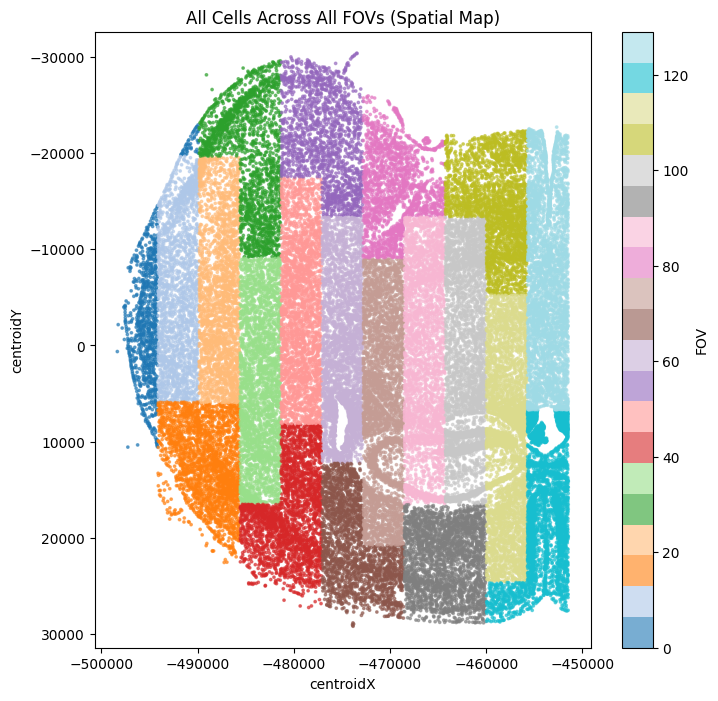

In [48]:
import matplotlib.pyplot as plt

# --- full dataset ---
adata_plot = adata.copy()

# --- spatial coordinates ---
coords = adata_plot.obsm["spatial"]
x, y = coords[:, 0], coords[:, 1]

# --- optional: color by FOV if available ---
if "fov" in adata_plot.obs.columns:
    fov = adata_plot.obs["fov"].astype("category").cat.codes
else:
    fov = None

# --- plot ---
plt.figure(figsize=(8, 8))

if fov is not None:
    plt.scatter(x, y, s=3, c=fov, cmap="tab20", alpha=0.6)
    plt.colorbar(label="FOV")
else:
    plt.scatter(x, y, s=3, alpha=0.6)

plt.title("All Cells Across All FOVs (Spatial Map)")
plt.xlabel("centroidX")
plt.ylabel("centroidY")
plt.gca().invert_yaxis()
plt.axis("equal")
plt.show()

In [27]:
adata.obs_names

Index(['1_1', '1_2', '1_3', '1_4', '1_5', '1_6', '1_7', '1_8', '1_9', '1_10',
       ...
       '130_306', '130_307', '130_308', '130_309', '130_310', '130_311',
       '130_312', '130_313', '130_314', '130_315'],
      dtype='object', name='unique_cell', length=48556)

In [29]:
import pandas as pd

coords_df = pd.DataFrame(
    adata.obsm["spatial"],
    columns=["centroidX", "centroidY"],
    index=adata.obs_names
)
coords_df

,centroidX,centroidY
unique_cell,,
1_1,-494161.333333,10541.000000
1_2,-494201.333333,10413.000000
1_3,-496227.333333,10339.000000
1_4,-494275.333333,10083.000000
1_5,-494221.333333,9981.000000
...,...,...
130_311,-454977.000000,-21553.666667
130_312,-454318.000000,-21757.666667
130_313,-454259.000000,-22258.666667


In [ ]:
dist_matrix